# Identifying Player Roles From Event Data

In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from matplotlib.patches import Rectangle
from mplsoccer import Pitch
import seaborn as sns

from position_identification_alg import *
from visualization_tool import *

Loading statsbomb event data

In [86]:
from statsbombpy import sb

sb.competitions().tail(40)
sb.matches(2,27)
events = sb.events(3754058)

We will use the AFC Bournemouth vs. Leicester City game from Premier League 2015/16

In [87]:
events["x"] = events["location"].str[0]
events["y"] = 80 - events["location"].str[1]

In [88]:
events

,ball_receipt_outcome,ball_recovery_recovery_failure,carry_end_location,clearance_aerial_won,clearance_body_part,clearance_head,clearance_left_foot,clearance_right_foot,counterpress,dribble_nutmeg,...,substitution_replacement,substitution_replacement_id,tactics,team,team_id,timestamp,type,under_pressure,x,y
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,"{'formation': 442, 'lineup': [{'player': {'id'...",Leicester City,22,00:00:00.000,Starting XI,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,"{'formation': 4141, 'lineup': [{'player': {'id...",AFC Bournemouth,28,00:00:00.000,Starting XI,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,AFC Bournemouth,28,00:00:00.000,Half Start,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,Leicester City,22,00:00:00.000,Half Start,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,AFC Bournemouth,28,00:00:00.000,Half Start,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3571,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,Leicester City,22,00:21:56.150,Injury Stoppage,NaN,NaN,NaN
3572,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,AFC Bournemouth,28,00:48:25.020,Injury Stoppage,NaN,NaN,NaN
3573,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,Leicester City,22,00:48:27.226,Injury Stoppage,NaN,NaN,NaN
3574,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,"{'formation': 4141, 'lineup': [{'player': {'id...",AFC Bournemouth,28,00:21:54.367,Tactical Shift,NaN,NaN,NaN


Here we will focus on Leicester City and identify player roles from their players' events.

We can identify their overall role using all the events they perform. However, we can also find in possession and out of possession roles as well.

To identify in possession roles we utilize events that occur when the team has the ball.

To identify out of possession roles we utilize events that occur when the team does not have the ball.

In [89]:
team_match_events = events[events.team_id==22]

starting_lineup = team_match_events[team_match_events.type=="Starting XI"].iloc[0].tactics["lineup"]
players = [player["player"]["id"] for player in starting_lineup if player["position"]["name"]!="Goalkeeper"]
team_subs = team_match_events[team_match_events.type == "Substitution"]


valid_events = ['Pass', 'Ball Receipt*', 'Carry','Pressure', 'Dispossessed', 'Duel', 'Shot', 'Block'
       'Ball Recovery', 'Miscontrol', 'Clearance', 'Dribbled Past','Dribble', 'Interception', 'Foul Committed', 'Foul Won']

in_possession_events =  ['Pass', 'Ball Receipt*', 'Carry', 'Dispossessed', 'Shot', 'Miscontrol', 'Clearance','Dribble', 'Foul Won']

out_possession_events = ['Pressure', 'Duel', 'Block''Ball Recovery', 'Dribbled Past', 'Interception', 'Foul Committed']

valid_team_match_events = team_match_events[team_match_events.type.isin(valid_events)]
valid_team_match_events = valid_team_match_events[valid_team_match_events.player_id!=0]

In [90]:
valid_team_match_events = valid_team_match_events[valid_team_match_events.player_id.isin(players)]

# Events for whole team

Below we show all the events performed by the starting 10 field players. At first it may seem daunting how we can identify roles from these events but I will break it down over the next few sections.

(<Figure size 1000x700 with 1 Axes>, <Axes: title={'center': 'Team Events'}>)

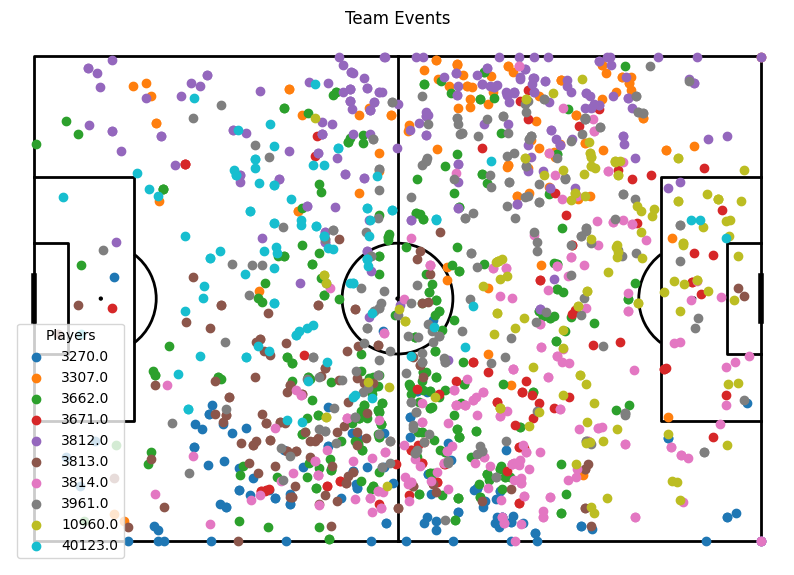

In [91]:
plot_team_events(valid_team_match_events)

# Events for a player

First step is to break down the team's events into each individual players events.

(<Figure size 1000x700 with 1 Axes>, <Axes: xlabel='x', ylabel='y'>)

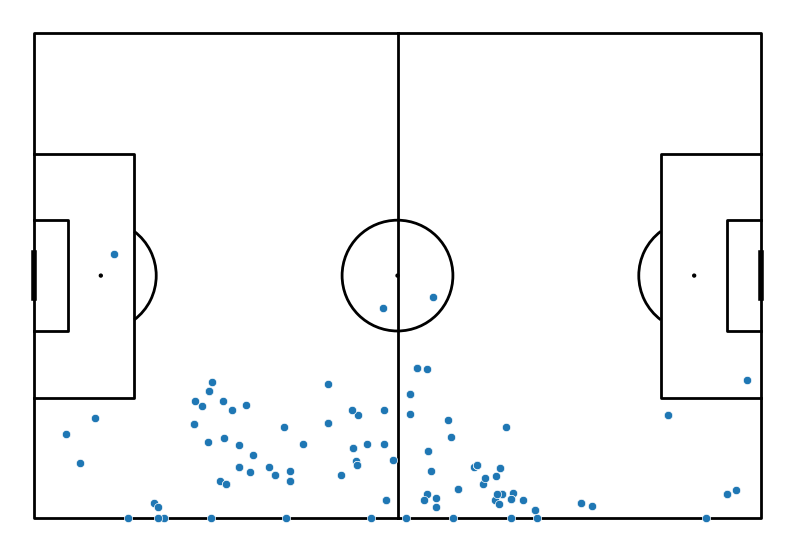

In [92]:
player_match_events = valid_team_match_events[valid_team_match_events.player_id==3270.0]

plot_player_events(player_match_events) 

# Estimating gaussian distribution of events for player.

Next step is to create a gaussian distribution to represent the events the player performs. This now gives us a model that shows the general positioning tendencies of the player throughout the game. These gaussians give us both a central tendency as well as variance in positioning these will be crucial for identifying roles later.

In [93]:
mu, Sigma = create_player_gaussian(player_match_events)

Here I show the gaussian model at .5 standard deviations.

(<Figure size 1000x700 with 1 Axes>, <Axes: xlabel='x', ylabel='y'>)

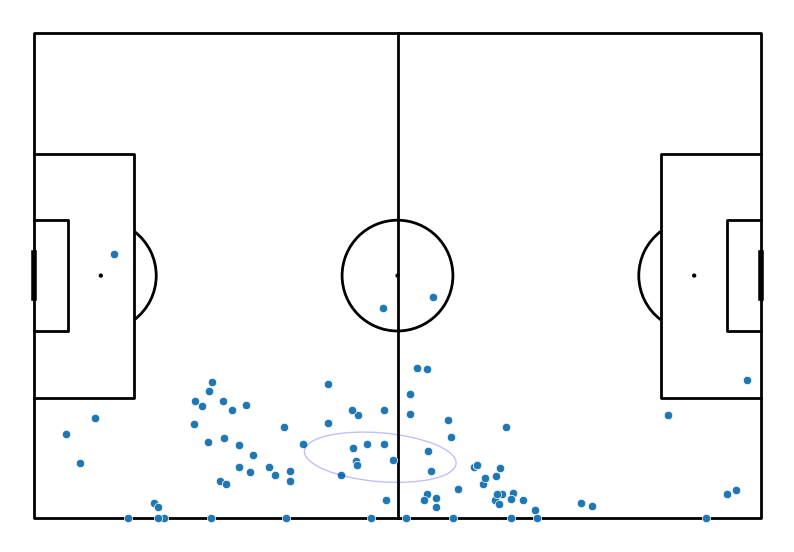

In [94]:
plot_player_gaussian(player_match_events,mu,Sigma)

# Gaussian Distributions of the Team

Now we can compute the gaussian models for each and every player. We can visualize the central tendency and variance of each of the player's positioning by events throughout the game

In [95]:
player_dists, zone_probs_df, player_pos = position_calculations(valid_team_match_events)

(<Figure size 1000x700 with 1 Axes>,
 <Axes: title={'center': 'Player Event Dists'}, xlabel='X', ylabel='Y'>)

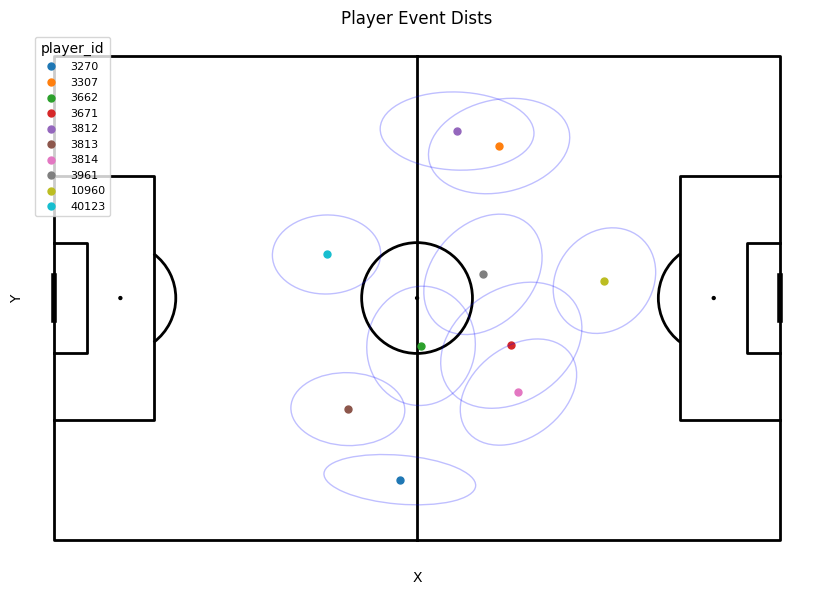

In [96]:
plot_team_player_gaussians(player_dists)

We can see that some of the player's roles are beggining to appear evident. But how can we actually assign the player's a role?

# Team Bounding
We can now create a box that tightly surronds the team. This box allows us to anchor the player's position compared to the team's general positioning. 

(<Figure size 1000x700 with 1 Axes>,
 <Axes: title={'center': 'Player Event Dists'}, xlabel='X', ylabel='Y'>)

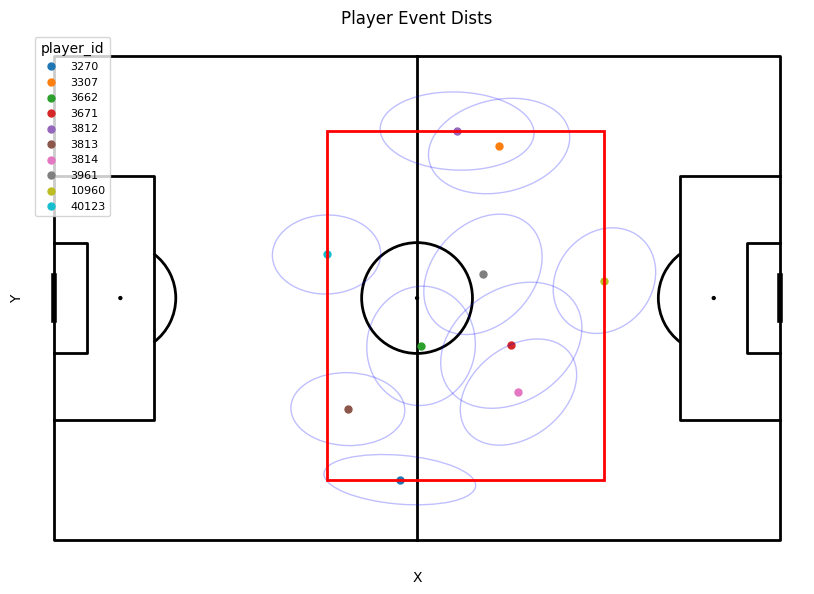

In [97]:
plot_team_player_gaussians(player_dists,with_box=True)

# Role assignements within box.

We can split the box into 5x5 cells where each cell represents a role. From left to right we represent our back to forward roles and from top to bottom we represent our left side to right side roles.

(<Figure size 1000x700 with 1 Axes>,
 <Axes: title={'center': 'Player Event Dists'}, xlabel='X', ylabel='Y'>)

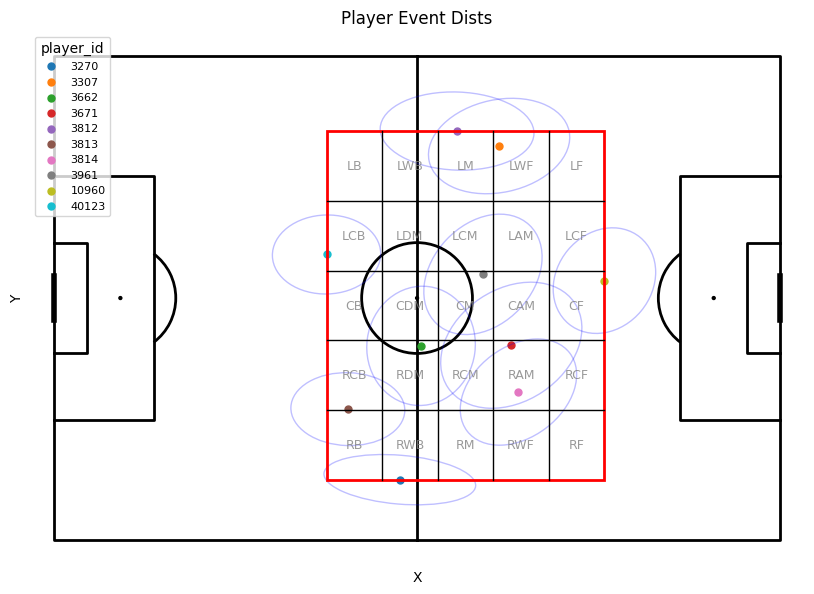

In [98]:
plot_team_player_gaussians(player_dists,with_box=True,with_cells=True,nx=5,ny=5)

# Calculate role probabilities

We can now calculate the probability the player falls into each of the 25 roles. We do this by utilizing the gaussian model that repreents the player's positioning and integrating over each zone to compute the probability the player fits into that role.

(<Figure size 2000x1000 with 2 Axes>,
 <Axes: title={'center': 'Player 3814 Role Probabilities'}>)

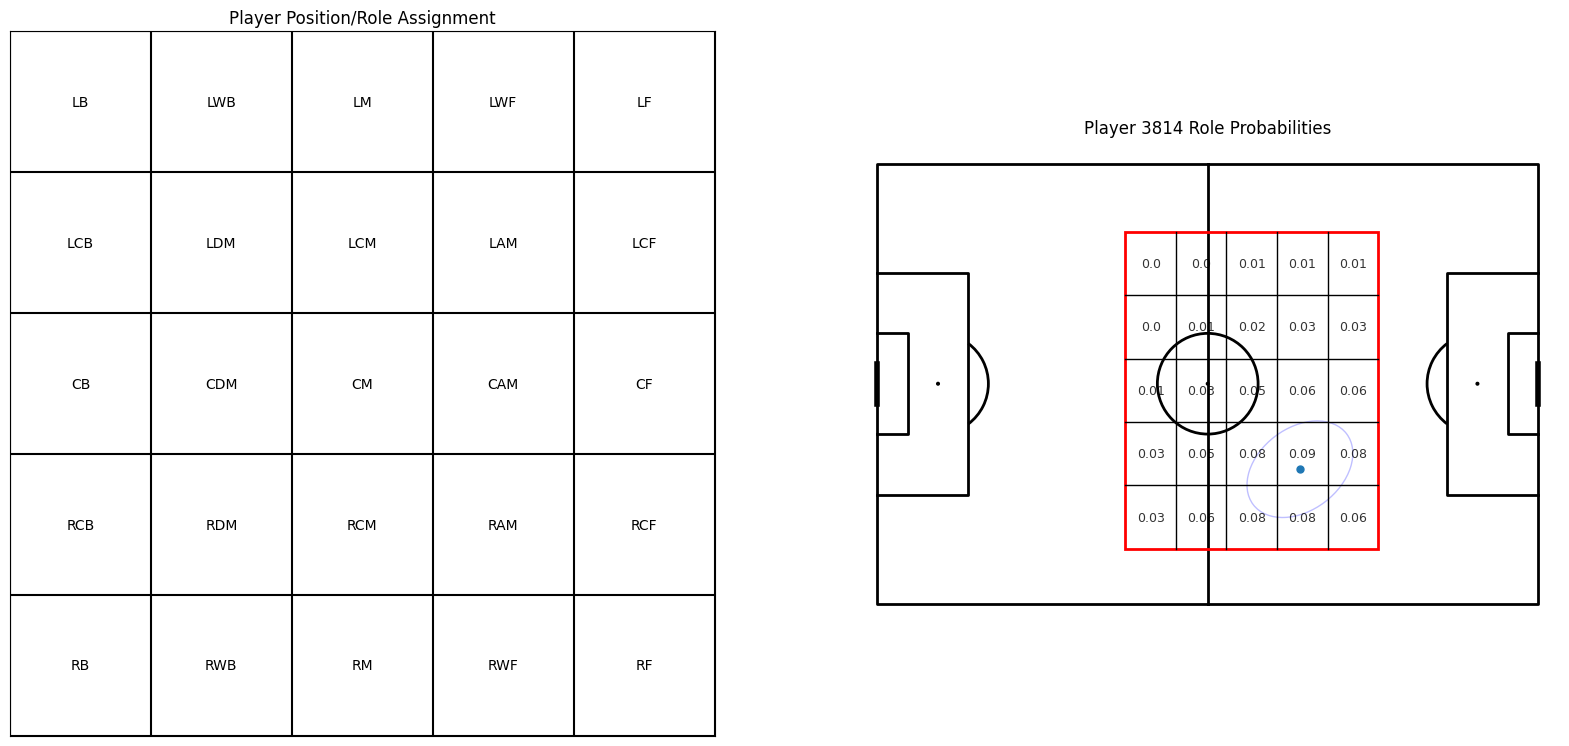

In [99]:
fig, axes = plt.subplots(1, 2, figsize=(20,10))

plot_role_assignments(ax=axes[0])
plot_player_role_probabilities(player_dists,zone_probs_df,3814,ax=axes[1])

# Find Each Player's Probable Role

We can now find the role that has the highest probability for the player and assign them that role. We can do that for each player.

(<Figure size 2000x1000 with 2 Axes>,
 <Axes: title={'center': 'Players by Most Probable Role'}>)

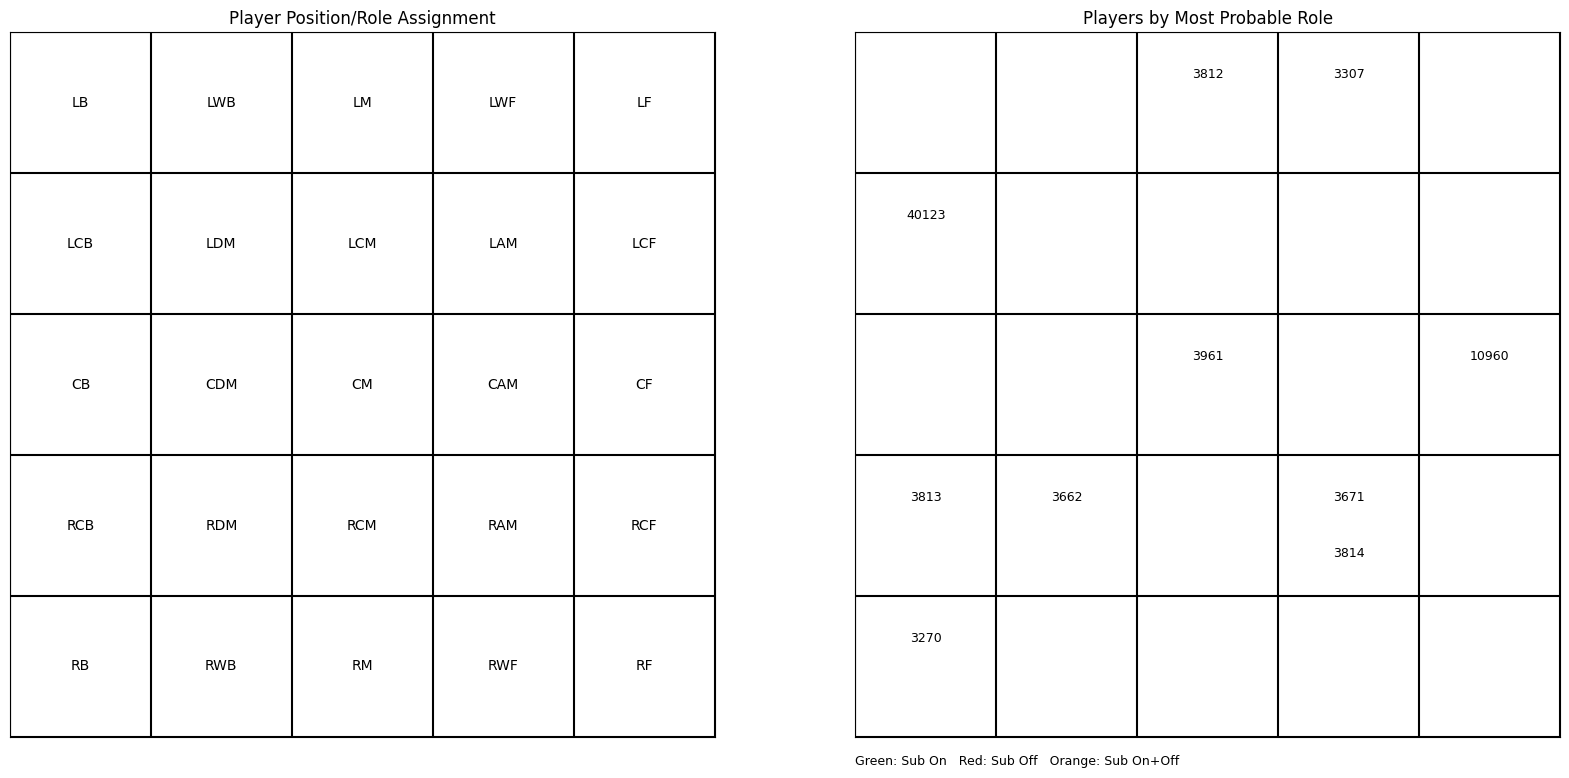

In [100]:
fig, axes = plt.subplots(1, 2, figsize=(20,10))

plot_role_assignments(ax=axes[0])

plot_player_probable_position(player_pos,team_subs,use_subbing=False,ax=axes[1])

# We can also compare how the player's role changes in posession vs. out of possession

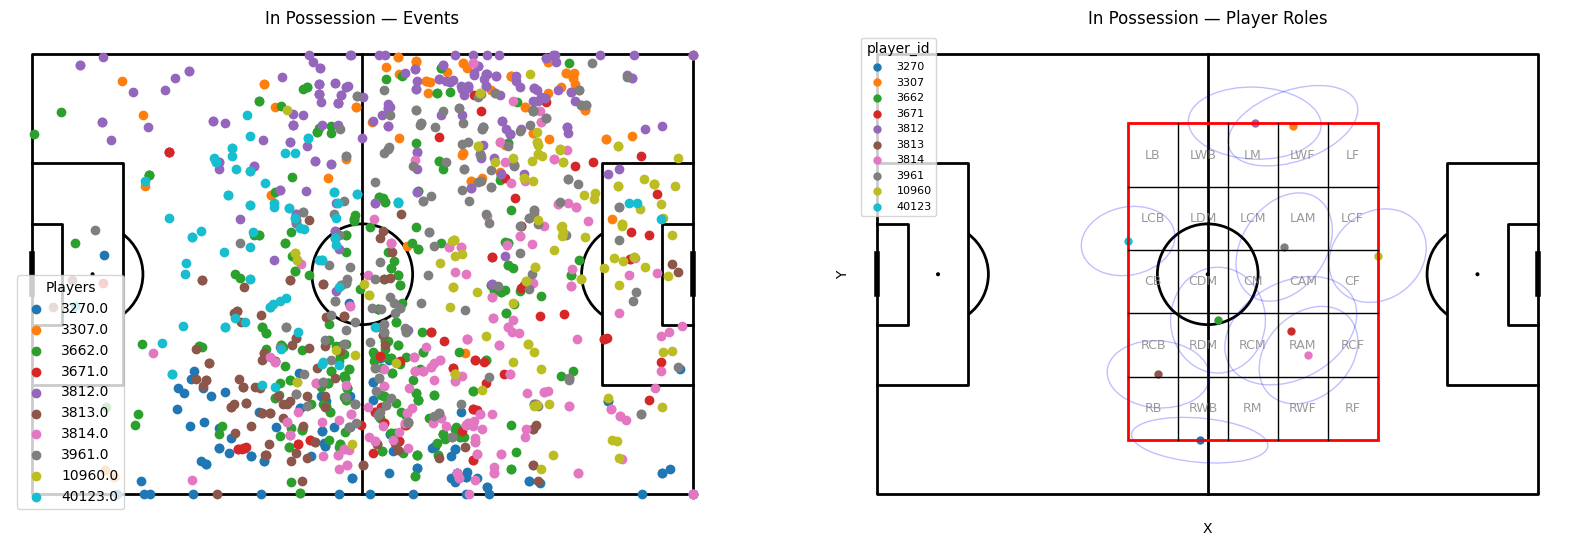

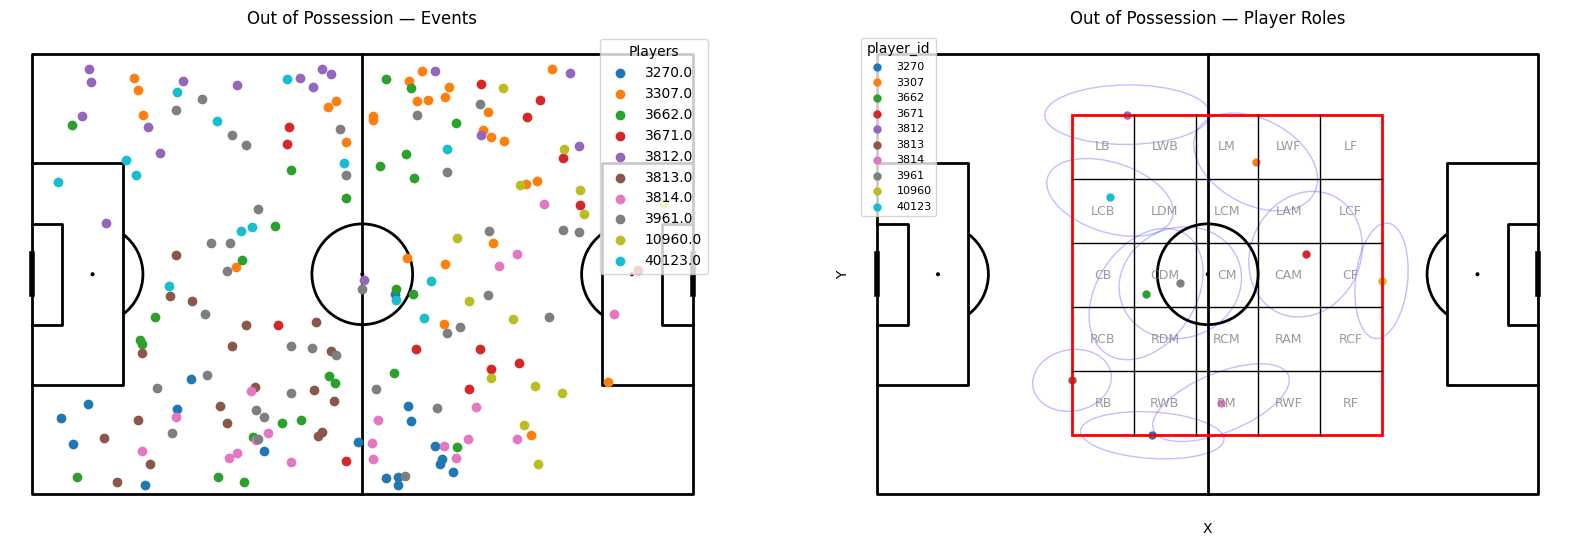

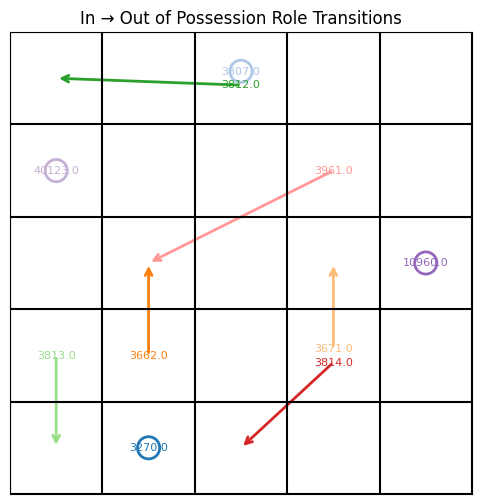

In [101]:
players = [player["player"]["id"] for player in starting_lineup if player["position"]["name"]!="Goalkeeper"]

valid_team_match_events = team_match_events[team_match_events.type.isin(in_possession_events)]
valid_team_match_events = valid_team_match_events[valid_team_match_events.player_id!=0]
valid_team_match_events = valid_team_match_events[valid_team_match_events.player_id.isin(players)]
player_dists_in, zone_probs_df_in, player_pos_in = position_calculations(valid_team_match_events)

fig, axes = plt.subplots(1, 2, figsize=(20,10))

plot_team_events(valid_team_match_events, ax=axes[0])
axes[0].set_title("In Possession — Events")

plot_team_player_gaussians(
    player_dists_in,
    with_box=True,
    with_cells=True,
    ax=axes[1]
)
axes[1].set_title("In Possession — Player Roles")
plt.show()

valid_team_match_events = team_match_events[team_match_events.type.isin(out_possession_events)]
valid_team_match_events = valid_team_match_events[valid_team_match_events.player_id!=0]
valid_team_match_events = valid_team_match_events[valid_team_match_events.player_id.isin(players)]
player_dists_out, zone_probs_df_out, player_pos_out = position_calculations(valid_team_match_events)

fig, axes = plt.subplots(1, 2, figsize=(20,10))

plot_team_events(valid_team_match_events, ax=axes[0])
axes[0].set_title("Out of Possession — Events")

plot_team_player_gaussians(
    player_dists_out,
    with_box=True,
    with_cells=True,
    ax=axes[1]
)
axes[1].set_title("Out of Possession — Player Roles")
plt.show()

plot_role_transition_arrows(player_pos_in=player_pos_in,player_pos_out=player_pos_out,zone_name_grid=zone_name_grid)
plt.show()

By breaking down the role into in possession and out of possession we are now able to identify key characteristics and play styles of players that are otherwise not clear in traditional "position" labels. 

# How can we deal with substitutions?

The same 10 field players are not on the field, so how can we take this into consideration when assigning player roles. One approach to this problem is to break the events up between substitutions and to calculate player role probabilities between each sub. We can then sum up all the broken player role maps to create a final role probability map for a player.

This allows the players role to be flexible to the players that are currently on the field. However, not all segments are equal some subs occur in close proximity so there is not a lot of events that occur in the short segment.  We utilize weighting by the segment duration to take this into consideration and not heavily impact the player's final role assignment.

Start of game
Duration: 45


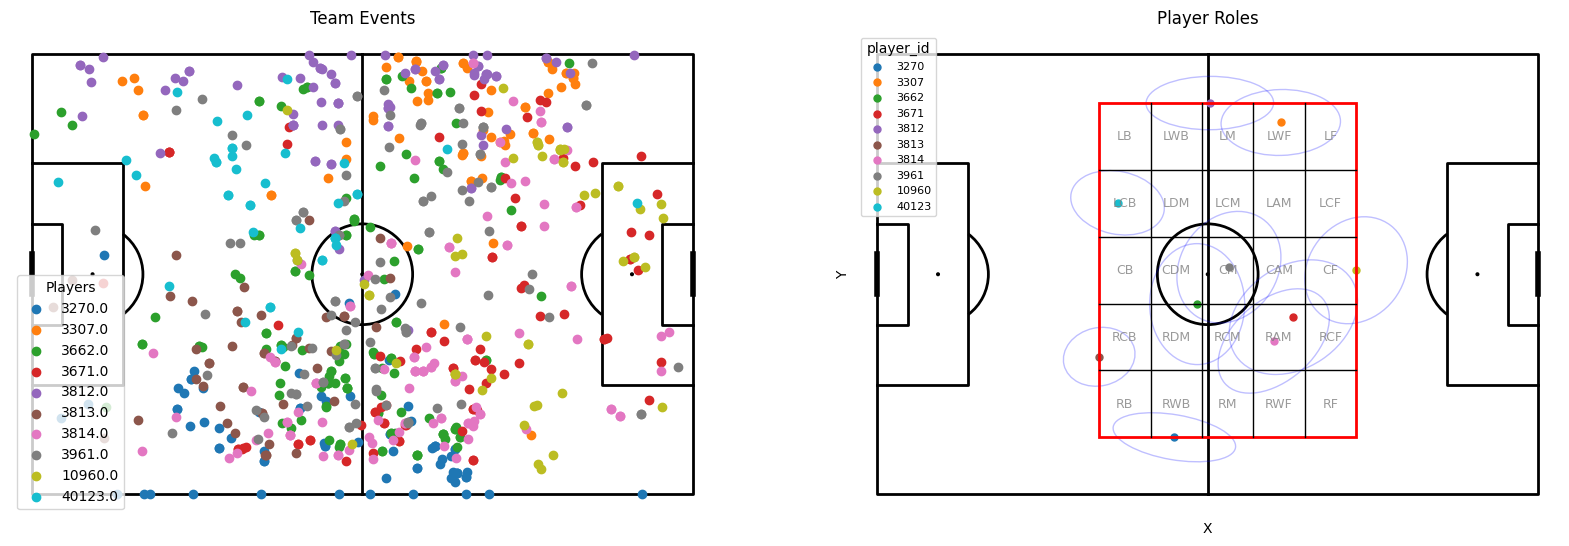

After sub 1
Duration: 19


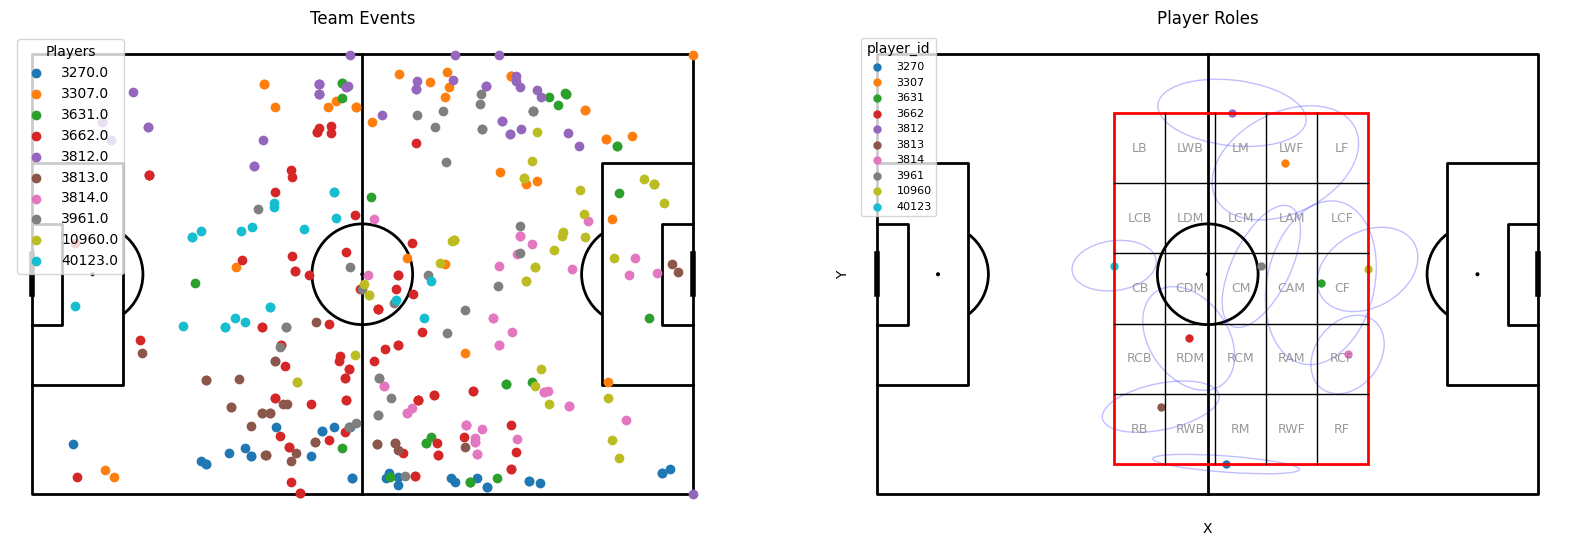

After sub 2
Duration: 9


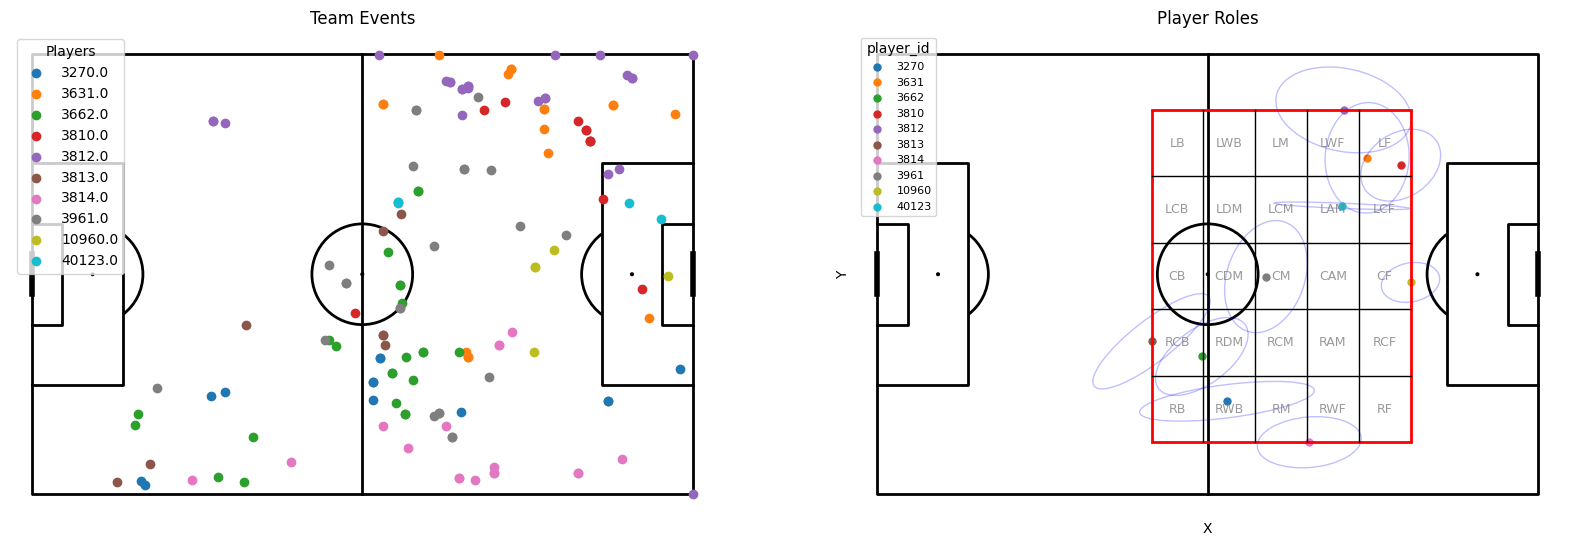

After sub 3
Duration: 21


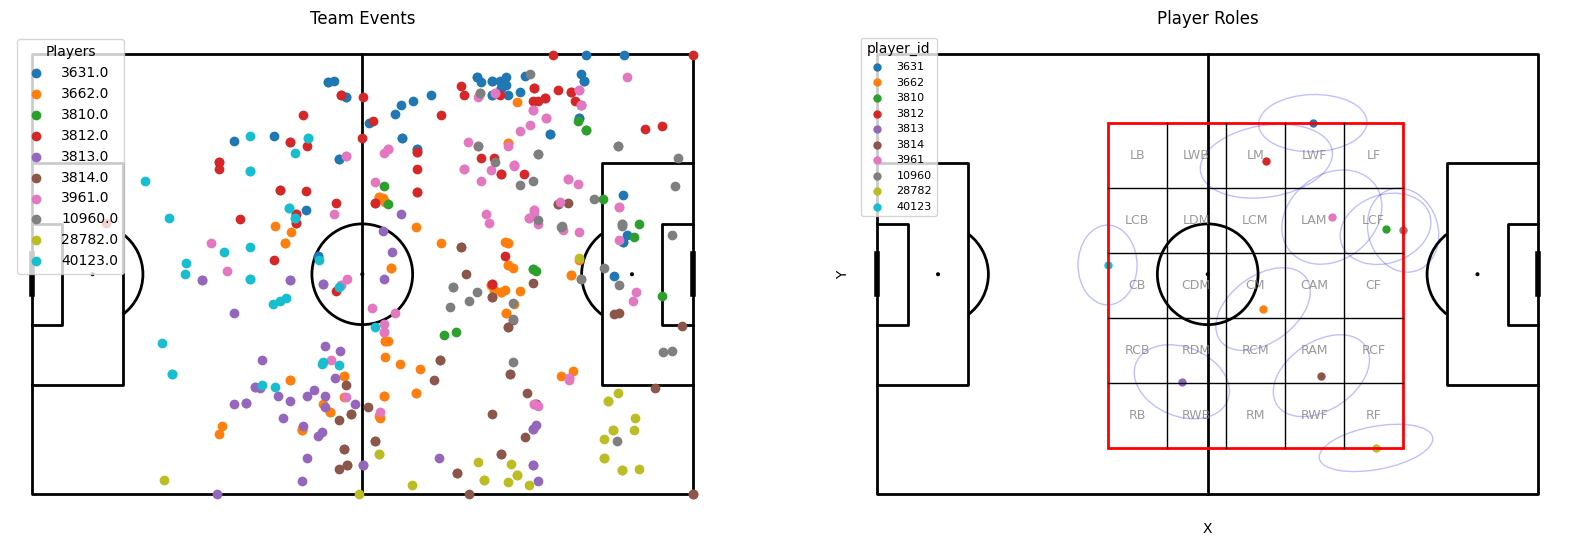

In [102]:
players = [player["player"]["id"] for player in starting_lineup if player["position"]["name"]!="Goalkeeper"]


valid_team_match_events = team_match_events[team_match_events.type.isin(valid_events)]
valid_team_match_events = valid_team_match_events[valid_team_match_events.player_id!=0]
first_sub = team_subs.iloc[0]
valid_team_match_events = valid_team_match_events[(valid_team_match_events.minute<=first_sub.minute)]
valid_team_match_events = valid_team_match_events[valid_team_match_events.player_id.isin(players)]
duration = first_sub.minute
player_dists, zone_probs_df, player_pos = position_calculations(valid_team_match_events)
zone_probs_df["duration"] = duration

print("Start of game")
print("Duration:", duration)

fig, axes = plt.subplots(1, 2, figsize=(20,10))

plot_team_events(valid_team_match_events, ax=axes[0])
axes[0].set_title("Team Events")

plot_team_player_gaussians(
    player_dists,
    with_box=True,
    with_cells=True,
    ax=axes[1]
)
axes[1].set_title("Player Roles")
plt.show()

for i in range(team_subs.shape[0]):
    print(f"After sub {i+1}")

    valid_team_match_events = team_match_events[team_match_events.type.isin(valid_events)]
    valid_team_match_events = valid_team_match_events[valid_team_match_events.player_id!=0]

    sub = team_subs.iloc[i]
    player_in = int(sub["substitution_replacement_id"])
    player_out = int(sub["player_id"])

    period = sub["period"]
    minute = sub["minute"]
    players.remove(player_out)
    players.append(player_in)
    
    if i+1 < team_subs.shape[0]:
        next_sub = team_subs.iloc[i+1]
        next_period = next_sub["period"]
        next_minute = next_sub["minute"]
    else:
        max_minute =  team_match_events["minute"].max()
        next_period = 2
        next_minute = max_minute
    
    duration = next_minute-minute
    print("Duration:", duration)
    
    valid_team_match_events = valid_team_match_events[(valid_team_match_events.period >= period) & (valid_team_match_events.minute>=minute) & (valid_team_match_events.period <= next_period) & (valid_team_match_events.minute<=next_minute)]
    valid_team_match_events = valid_team_match_events[valid_team_match_events.player_id.isin(players)]
    
    player_dists_sub, zone_probs_df_sub, player_pos_sub = position_calculations(valid_team_match_events)
    
    zone_probs_df_sub["duration"] = duration
    
    zone_probs_df = pd.concat([zone_probs_df,zone_probs_df_sub])
    
    fig, axes = plt.subplots(1, 2, figsize=(20,10))

    plot_team_events(valid_team_match_events, ax=axes[0])
    axes[0].set_title("Team Events")

    plot_team_player_gaussians(
        player_dists_sub,
        with_box=True,
        with_cells=True,
        ax=axes[1]
    )
    axes[1].set_title("Player Roles")
    plt.show()

We compute the player role probabilities for each segment below

In [103]:
zone_probs_df

,RB,RWB,RM,RWF,RF,RCB,RDM,RCM,RAM,RCF,...,LDM,LCM,LAM,LCF,LB,LWB,LM,LWF,LF,duration
player_id,,,,,,,,,,,,,,,,,,,,,
3270.0,2.385793e-01,2.362206e-01,1.922502e-01,1.285966e-01,7.068754e-02,4.742540e-02,3.816244e-02,2.520992e-02,1.366901e-02,6.082028e-03,...,2.978082e-06,1.255154e-06,4.333468e-07,1.225461e-07,3.028328e-09,1.233758e-09,4.116083e-10,1.124402e-10,2.514779e-11,45
40123.0,1.669776e-03,1.787095e-03,1.414897e-03,8.286467e-04,3.589473e-04,2.117889e-02,2.075485e-02,1.504774e-02,8.071034e-03,3.202085e-03,...,1.307830e-01,7.977670e-02,3.600180e-02,1.201752e-02,9.539679e-02,7.216135e-02,4.038491e-02,1.671916e-02,5.119170e-03,45
3961.0,2.414403e-02,3.165585e-02,3.244653e-02,2.599881e-02,1.628534e-02,3.787798e-02,5.227193e-02,5.639233e-02,4.756039e-02,3.135702e-02,...,4.857840e-02,5.805670e-02,5.424196e-02,3.961764e-02,1.699023e-02,2.733945e-02,3.439046e-02,3.381872e-02,2.599841e-02,45
3662.0,3.829523e-02,4.967710e-02,4.845651e-02,3.554103e-02,1.960029e-02,5.153632e-02,6.678024e-02,6.506791e-02,4.767248e-02,2.626171e-02,...,4.939432e-02,4.802218e-02,3.510660e-02,1.929699e-02,2.104168e-02,2.717588e-02,2.639195e-02,1.927263e-02,1.058192e-02,45
3812.0,1.049910e-07,1.228417e-07,1.224743e-07,1.040518e-07,7.532808e-08,3.297331e-05,3.882648e-05,3.895823e-05,3.331010e-05,2.426923e-05,...,4.509183e-02,4.580656e-02,3.965188e-02,2.924853e-02,1.495697e-01,1.793620e-01,1.832837e-01,1.595966e-01,1.184209e-01,45
10960.0,6.320689e-03,1.567414e-02,3.022439e-02,4.532360e-02,5.285772e-02,9.067068e-03,2.361088e-02,4.780843e-02,7.528094e-02,9.218939e-02,...,1.675907e-02,3.741746e-02,6.496384e-02,8.771522e-02,2.618386e-03,7.895522e-03,1.851148e-02,3.374923e-02,4.785034e-02,45
3307.0,1.747340e-05,2.618331e-05,3.269169e-05,3.401112e-05,2.948332e-05,5.867085e-04,8.915977e-04,1.128968e-03,1.191150e-03,1.047186e-03,...,5.637066e-02,7.337119e-02,7.957404e-02,7.191052e-02,6.770843e-02,1.072098e-01,1.414468e-01,1.554983e-01,1.424406e-01,45
3671.0,2.933296e-02,4.322227e-02,5.370974e-02,5.628542e-02,4.974352e-02,3.133815e-02,4.934850e-02,6.553402e-02,7.339341e-02,6.931812e-02,...,2.207593e-02,3.348282e-02,4.282671e-02,4.619576e-02,4.498209e-03,8.646827e-03,1.401670e-02,1.916093e-02,2.208900e-02,45
3813.0,1.794539e-01,1.040725e-01,3.669278e-02,7.856211e-03,1.020005e-03,2.354418e-01,1.461326e-01,5.514798e-02,1.264112e-02,1.757532e-03,...,8.599407e-03,3.723771e-03,9.796210e-04,1.563594e-04,4.544714e-04,3.473990e-04,1.614735e-04,4.560000e-05,7.813965e-06,45


Then we can perform our weighted average (by duration) to find the final role probability map

In [104]:
def weighted_positioning(df):
    zone_cols = [c for c in df.columns if  c != "duration"]
    
    total_min = df["duration"].sum()
    
    weights = df["duration"] / total_min
    return (df[zone_cols].multiply(weights, axis=0)).sum()

role_probs = zone_probs_df.groupby("player_id").apply(weighted_positioning)

In [105]:
role_probs

,RB,RWB,RM,RWF,RF,RCB,RDM,RCM,RAM,RCF,...,LCB,LDM,LCM,LAM,LCF,LB,LWB,LM,LWF,LF
player_id,,,,,,,,,,,,,,,,,,,,,
3270.0,0.233554,0.232573,0.194552,0.137057,0.081750,0.034278,0.030341,0.023747,0.017227,0.012162,...,3.581545e-06,1.870699e-06,8.567418e-07,4.419941e-07,4.016851e-07,1.866852e-09,7.608268e-10,2.547284e-10,7.233839e-11,2.362594e-11
3307.0,0.001766,0.001805,0.001614,0.001264,0.000867,0.005868,0.006640,0.006593,0.005731,0.004349,...,4.059862e-02,5.928858e-02,7.378713e-02,7.788962e-02,6.953539e-02,6.127646e-02,9.447584e-02,1.227934e-01,1.342962e-01,1.235143e-01
3631.0,0.006182,0.011236,0.016549,0.019614,0.018578,0.007637,0.014811,0.023253,0.029110,0.028699,...,1.569602e-02,3.341735e-02,5.516675e-02,6.989302e-02,6.747365e-02,3.074782e-02,6.493831e-02,1.041947e-01,1.266096e-01,1.162267e-01
3662.0,0.044296,0.053629,0.048239,0.032241,0.016084,0.060462,0.079201,0.074793,0.050694,0.024727,...,3.080858e-02,4.034744e-02,4.229975e-02,3.443934e-02,2.073036e-02,1.413481e-02,1.741171e-02,1.756003e-02,1.450811e-02,9.436798e-03
3671.0,0.029333,0.043222,0.053710,0.056285,0.049744,0.031338,0.049349,0.065534,0.073393,0.069318,...,1.227430e-02,2.207593e-02,3.348282e-02,4.282671e-02,4.619576e-02,4.498209e-03,8.646827e-03,1.401670e-02,1.916093e-02,2.208900e-02
3810.0,0.000396,0.001387,0.003186,0.004800,0.004745,0.001854,0.007178,0.018195,0.030225,0.032926,...,3.996350e-03,1.929954e-02,6.068559e-02,1.243779e-01,1.663111e-01,1.825659e-03,1.000889e-02,3.566475e-02,8.265102e-02,1.246346e-01
3812.0,0.000104,0.000115,0.000110,0.000095,0.000078,0.001219,0.001456,0.001478,0.001312,0.001056,...,4.237581e-02,5.430674e-02,5.938251e-02,5.563974e-02,4.503005e-02,1.182421e-01,1.478005e-01,1.586592e-01,1.462115e-01,1.158691e-01
3813.0,0.145456,0.107423,0.061015,0.028263,0.010845,0.174512,0.128939,0.069581,0.031514,0.013406,...,1.115629e-02,1.170269e-02,9.895663e-03,6.100198e-03,2.432756e-03,6.750736e-04,8.619054e-04,1.458370e-03,2.079113e-03,1.816276e-03
3814.0,0.031280,0.058770,0.087571,0.100027,0.084260,0.018955,0.041565,0.073716,0.101146,0.101702,...,2.285731e-03,6.206588e-03,1.362422e-02,2.368809e-02,3.122942e-02,4.121595e-04,1.244085e-03,2.977075e-03,5.615716e-03,8.166472e-03


Then we can find the most probable role to assign to each player

In [106]:
player_roles = role_probs.idxmax(axis=1)

(<Figure size 2000x1000 with 2 Axes>,
 <Axes: title={'center': 'Players by Most Probable Role'}>)

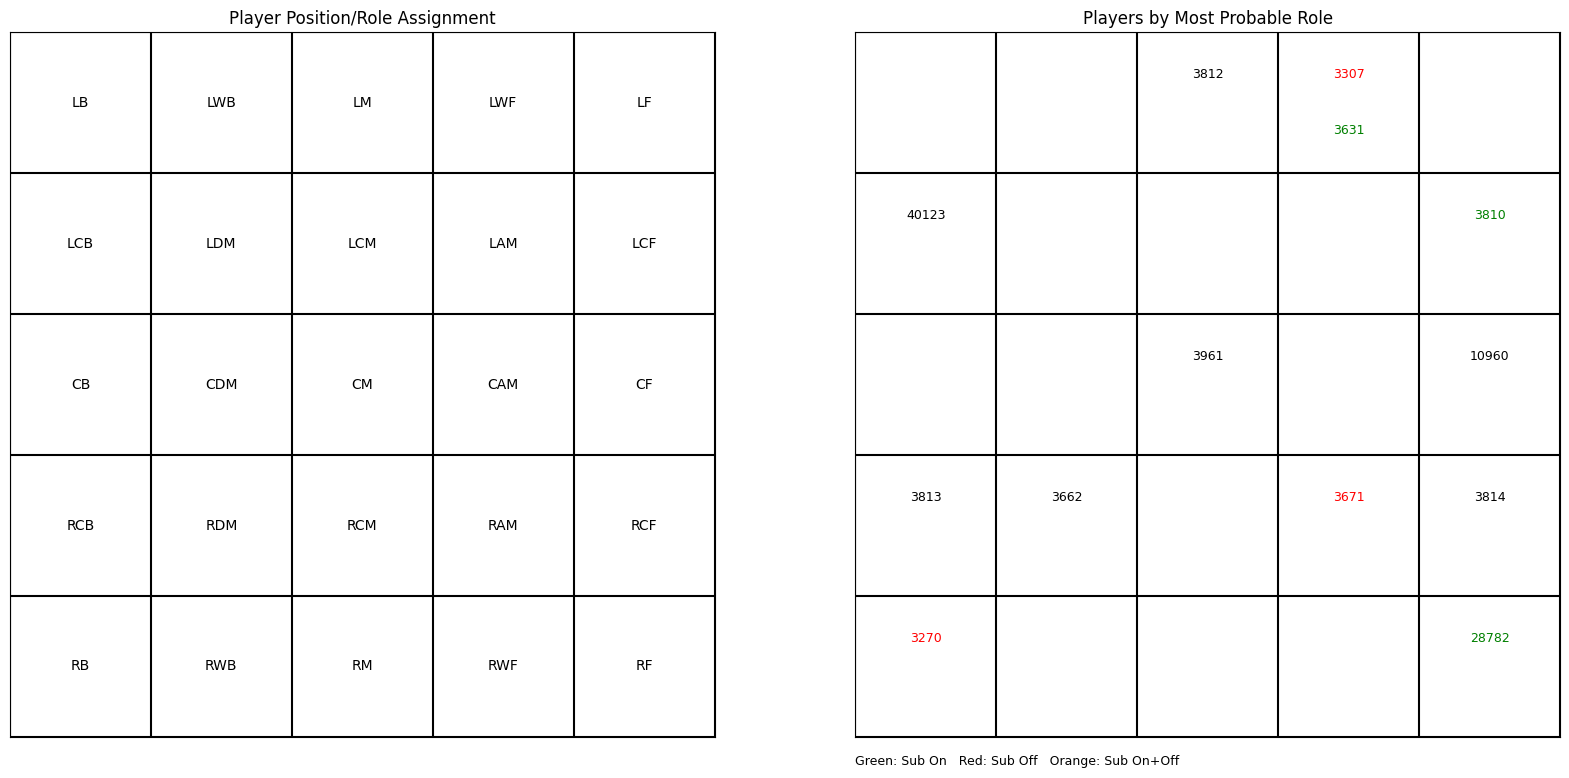

In [107]:
fig, axes = plt.subplots(1, 2, figsize=(20,10))

plot_role_assignments(ax=axes[0])
plot_player_probable_position(player_roles,team_subs,ax=axes[1])

In [108]:
player_actual_position = team_match_events[["player_id","position"]].dropna().drop_duplicates().set_index("player_id")
role_probs["actual_position"] = player_actual_position

# Conclusion

In this notebook we looked at how we can identify player roles from event data. Here player roles defines the role that a player takes within a teams formation. We utilize gaussian functions to model each of the player's positioning from events. We then bound all the teams gaussians into a box to anchor the player relationships and identify the roles played among players of a team. We use a 5x5 grid within the box with each cell representing a role. We are able to then use integration to find the probability of each player falling into a role. Overall this models the process for how we can assign roles from event data.

We are able to utilize defensive vs. offenive events to assign players different roles for when the team is in possession vs. out of possession. This enables us to learn even more information about the role a player takes when the team is in different scenarios. This also allows us to look at how players transitiion between phases of play and how their role changes. 

To make this approach usable we show a method for how to incorporate this model to work within game substitutions by breaking the game into segements between subs and computing player role probability maps for each segment then using weighted averages to bring together each of the segments into a final role probability map that can be used to assign player roles. 

These approaches help to assign and detect player roles without tracking data which is not available everywhere and gives coaches, analysts, and scouts the ability to analyze and compare players based off the role they play from the actions that they perform during the game. 